# 03 — Statistics & Probability

The EDA (notebook 02) *suggested* four churn drivers. This notebook applies formal
statistical rigor:

1. **Probability & Bayes** — base rates and compound risk
2. **Hypothesis testing** — chi-square / Mann-Whitney with **multiple-testing correction**
   and **effect sizes** (p-values alone are not enough)
3. **Bootstrap confidence intervals** — quantifying the onboarding cliff
4. **Survival analysis** — Kaplan-Meier + Cox proportional hazards (churn *is* a
   time-to-event problem)
5. **A/B test design** — power analysis for the retention experiment these findings imply

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

ROOT = Path.cwd()
if not (ROOT / "config").exists():
    ROOT = ROOT.parent
FIG = ROOT / "reports" / "figures"

rng = np.random.default_rng(42)
df = pd.read_parquet(ROOT / "data" / "interim" / "churn_clean.parquet")
df.shape

(10000, 31)

## 1. Probability & Bayes

Churn is rare (10.2%), so conditional probabilities matter more than raw correlations.
How much does knowing a risk factor *update* our belief that a customer will churn?

In [2]:
p_churn = df["churn"].mean()
low_csat = df["csat_score"] <= 2
pf2 = df["payment_failures"] >= 2

print(f"Prior:                      P(churn)                    = {p_churn:.3f}")
print(f"Posterior (low CSAT):       P(churn | csat<=2)          = {df.loc[low_csat, 'churn'].mean():.3f}")
print(f"Posterior (payment issues): P(churn | failures>=2)      = {df.loc[pf2, 'churn'].mean():.3f}")
print(f"Posterior (both):           P(churn | both)             = {df.loc[low_csat & pf2, 'churn'].mean():.3f}"
      f"   (n={int((low_csat & pf2).sum())})")

# Bayes' theorem check: P(churn|A) = P(A|churn) P(churn) / P(A)
p_A = low_csat.mean()
p_A_given_churn = low_csat[df["churn"] == 1].mean()
print(f"\nBayes verification: P(A|churn)*P(churn)/P(A) = "
      f"{p_A_given_churn * p_churn / p_A:.3f}  (matches the direct estimate)")

Prior:                      P(churn)                    = 0.102
Posterior (low CSAT):       P(churn | csat<=2)          = 0.257
Posterior (payment issues): P(churn | failures>=2)      = 0.247
Posterior (both):           P(churn | both)             = 0.373   (n=150)

Bayes verification: P(A|churn)*P(churn)/P(A) = 0.257  (matches the direct estimate)


**Read:** a low CSAT score multiplies churn risk **2.5×** (10.2% → 25.7%), ≥2 payment
failures **2.4×** (→ 24.7%), and the two *stack*: a customer with both churns at
**37.3%** — nearly 4× the base rate. Also note base-rate reasoning: even though churned
customers are ~4× more likely to have low CSAT, most low-CSAT customers still *don't*
churn (74%) — precision will be a challenge for any targeting model.

## 2. Hypothesis testing with effect sizes

We test **every** feature against churn — categoricals with chi-square (+ Cramér's V),
numerics with Mann-Whitney U (+ Cohen's d; distributions are skewed so a rank test is
safer than the t-test). Running 23 tests means ~1 false positive at α=0.05 by chance
alone, so we control the false-discovery rate with **Benjamini-Hochberg**.

In [3]:
from statsmodels.stats.multitest import multipletests

results = []

cats = ["customer_segment", "contract_type", "payment_method", "complaint_type",
        "survey_response", "gender", "country", "signup_channel"]
for c in cats:
    ct = pd.crosstab(df[c], df["churn"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))  # Cramer's V
    results.append({"feature": c, "test": "chi-square", "p": p, "effect": v,
                    "effect_metric": "Cramer's V"})

nums = ["tenure_months", "csat_score", "payment_failures", "last_login_days_ago",
        "monthly_logins", "avg_session_time", "nps_score", "age", "monthly_fee",
        "weekly_active_days", "features_used", "usage_growth_rate", "support_tickets",
        "email_open_rate", "escalations"]
for c in nums:
    a, b = df.loc[df["churn"] == 1, c], df.loc[df["churn"] == 0, c]
    _, p = stats.mannwhitneyu(a, b)
    pooled = np.sqrt(((len(a) - 1) * a.std() ** 2 + (len(b) - 1) * b.std() ** 2)
                     / (len(a) + len(b) - 2))
    results.append({"feature": c, "test": "mann-whitney", "p": p,
                    "effect": (a.mean() - b.mean()) / pooled, "effect_metric": "Cohen's d"})

res = pd.DataFrame(results)
res["p_adj_BH"] = multipletests(res["p"], alpha=0.05, method="fdr_bh")[1]
res["significant"] = res["p_adj_BH"] < 0.05
res.sort_values("p_adj_BH").round(4)

,feature,test,p,effect,effect_metric,p_adj_BH,significant
9,csat_score,mann-whitney,0.0000,-0.5282,Cohen's d,0.0000,True
8,tenure_months,mann-whitney,0.0000,-0.3891,Cohen's d,0.0000,True
12,monthly_logins,mann-whitney,0.0000,-0.3263,Cohen's d,0.0000,True
10,payment_failures,mann-whitney,0.0000,0.3739,Cohen's d,0.0000,True
11,last_login_days_ago,mann-whitney,0.1231,0.1231,Cohen's d,0.5665,False
0,customer_segment,chi-square,0.2560,0.0165,Cramer's V,0.6688,False
7,signup_channel,chi-square,0.2773,0.0160,Cramer's V,0.6688,False
4,survey_response,chi-square,0.2481,0.0167,Cramer's V,0.6688,False
15,age,mann-whitney,0.3038,0.0335,Cohen's d,0.6688,False
22,escalations,mann-whitney,0.3511,0.0316,Cohen's d,0.6688,False


**Read — only 4 of 23 features survive correction:**

| Feature | Effect size | Direction |
|---|---|---|
| `csat_score` | d = **−0.53** (medium) | lower CSAT → churn |
| `tenure_months` | d = −0.39 (small-medium) | newer → churn |
| `payment_failures` | d = +0.37 (small-medium) | more failures → churn |
| `monthly_logins` | d = −0.33 (small-medium) | less usage → churn |

Everything else — including **every categorical** (all Cramér's V < 0.025, trivial) and
`nps_score` (p = 0.95!) — is statistically indistinguishable from noise.

**The `last_login_days_ago` lesson:** EDA showed churn *doubling* past 30 days, yet the
global rank test says p = 0.12. No contradiction — the effect is **threshold-shaped** and
only ~4% of customers sit past the threshold, so a whole-distribution test dilutes it.
(The Cox model below, which conditions on other covariates, recovers it at p = 0.003.)
This is precisely why Phase 4 will engineer **bucketed threshold features** instead of
feeding raw values to linear models.

## 3. Bootstrap CI: how big is the onboarding cliff?

A p-value says the early-tenure gap isn't chance; a **confidence interval** says how big
it is — which is what a retention budget decision actually needs.

churn gap (first 6 months vs rest): 19.9%   95% CI (17.1%, 22.9%)


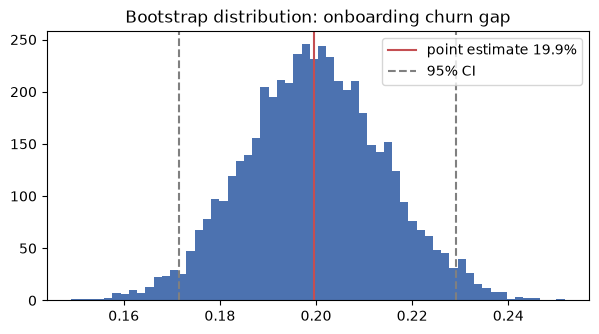

In [4]:
early = df.loc[df["tenure_months"] <= 6, "churn"].to_numpy()
late = df.loc[df["tenure_months"] > 6, "churn"].to_numpy()

point = early.mean() - late.mean()
boots = np.array([
    rng.choice(early, len(early)).mean() - rng.choice(late, len(late)).mean()
    for _ in range(5000)
])
lo, hi = np.percentile(boots, [2.5, 97.5])
print(f"churn gap (first 6 months vs rest): {point:.1%}   95% CI ({lo:.1%}, {hi:.1%})")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(boots, bins=60, color="#4c72b0")
ax.axvline(point, c="#c44e52", label=f"point estimate {point:.1%}")
ax.axvline(lo, c="grey", ls="--"); ax.axvline(hi, c="grey", ls="--", label="95% CI")
ax.set_title("Bootstrap distribution: onboarding churn gap")
ax.legend()
fig.savefig(FIG / "07_bootstrap_gap.png", dpi=150, bbox_inches="tight")
plt.show()

**Read:** new customers churn **20 percentage points more** (95% CI: 17.2–22.9pp).
Even the CI's pessimistic edge is a huge effect — the onboarding cliff is real, precisely
estimated, and worth money.

## 4. Survival analysis: churn as time-to-event

Classification asks *"who churns?"*; survival analysis asks *"**when**, and what
accelerates it?"* — retained customers aren't non-events, they're **right-censored**
(they just haven't churned *yet*). `tenure_months` is the duration, `churn` the event.

> Nuance: EDA's "28% churn in the ≤6-month cohort" is a *cross-sectional snapshot* (it
> conditions on currently being early-tenure). The Kaplan-Meier curve below is the proper
> *longitudinal* view of the same lifecycle.

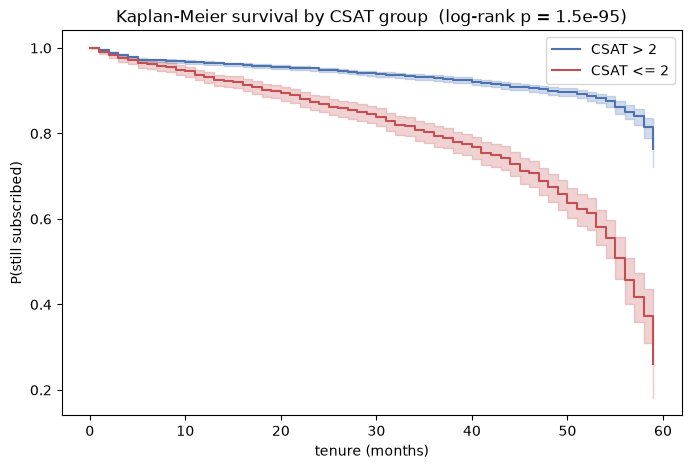

In [5]:
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test

fig, ax = plt.subplots(figsize=(8, 5))
kmf = KaplanMeierFitter()

low = df["csat_score"] <= 2
for mask, label, color in [(~low, "CSAT > 2", "#4c72b0"), (low, "CSAT <= 2", "#c44e52")]:
    kmf.fit(df.loc[mask, "tenure_months"], df.loc[mask, "churn"], label=label)
    kmf.plot_survival_function(ax=ax, color=color)

lr = logrank_test(df.loc[low, "tenure_months"], df.loc[~low, "tenure_months"],
                  df.loc[low, "churn"], df.loc[~low, "churn"])
ax.set_title(f"Kaplan-Meier survival by CSAT group  (log-rank p = {lr.p_value:.1e})")
ax.set_xlabel("tenure (months)"); ax.set_ylabel("P(still subscribed)")
fig.savefig(FIG / "08_km_curves.png", dpi=150, bbox_inches="tight")
plt.show()

**Read:** the curves separate immediately and never recover (log-rank p ≈ 10⁻⁹⁵). By
month 24, low-CSAT customers retain at 86.9% vs 95.0% — dissatisfaction doesn't just
predict churn, it predicts *faster* churn.

### Cox proportional hazards — what accelerates churn, holding everything else constant?

concordance index: 0.648


,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,
csat_score,0.6356,0.5981,0.6756,0.0000
payment_failures,1.4484,1.3496,1.5544,0.0000
last_login_days_ago,1.0087,1.0030,1.0145,0.0029
monthly_logins,0.9688,0.9626,0.9750,0.0000
monthly_fee,0.9990,0.9964,1.0016,0.4430
discount_applied,0.9498,0.8292,1.0879,0.4572
weekly_active_days,0.9942,0.9682,1.0210,0.6691


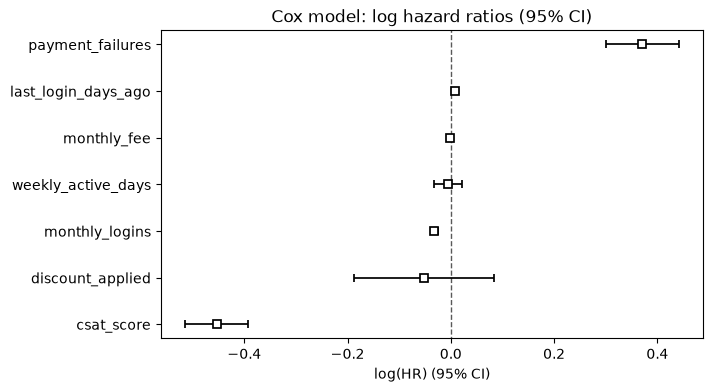

In [6]:
cph = CoxPHFitter()
covs = ["csat_score", "payment_failures", "last_login_days_ago", "monthly_logins",
        "monthly_fee", "discount_applied", "weekly_active_days"]
cph.fit(df[covs + ["tenure_months", "churn"]].astype(float),
        duration_col="tenure_months", event_col="churn")

print(f"concordance index: {cph.concordance_index_:.3f}")
display(cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].round(4))

fig, ax = plt.subplots(figsize=(7, 4))
cph.plot(ax=ax)
ax.set_title("Cox model: log hazard ratios (95% CI)")
fig.savefig(FIG / "09_cox_hazards.png", dpi=150, bbox_inches="tight")
plt.show()

**Read (hazard ratios):**
- Each **+1 CSAT point cuts churn hazard by ~36%** (HR 0.64) — the strongest lever.
- Each **payment failure raises hazard by ~45%** (HR 1.45).
- Each day since last login adds ~0.9% hazard (HR 1.009, p=0.003) — small per-day, large
  when 30+ days accumulate; consistent with the threshold story.
- `monthly_fee` and `discount_applied` are null — pricing doesn't accelerate churn.

Concordance 0.648: informative but far from deterministic — matching our expectation that
signals here are real but individually weak.

## 5. Designing the retention A/B test

Findings imply an experiment: give first-6-month customers (28.1% churn) an enhanced
onboarding + CSAT-recovery program. Before running it — **how many customers do we need?**
(α = 0.05, power = 0.80, two-sided)

In [7]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

baseline = 0.281
rows = []
for mde in [0.03, 0.05, 0.08]:
    es = proportion_effectsize(baseline, baseline - mde)
    n = NormalIndPower().solve_power(es, alpha=0.05, power=0.8, alternative="two-sided")
    rows.append({"MDE (pp)": int(mde * 100), "target rate": f"{baseline - mde:.1%}",
                 "n per arm": int(np.ceil(n))})
pd.DataFrame(rows)

,MDE (pp),target rate,n per arm
0,3,25.1%,3404
1,5,23.1%,1194
2,8,20.1%,446


**Read:** detecting a realistic 5pp reduction (28.1% → 23.1%) needs **1,194 customers
per arm**. With ~1,000 customers in the early-tenure cohort at any time, the experiment
would run over ~2–3 signup cohorts. Guardrail metrics: CSAT, support-ticket volume, and
30-day activity rate — so a "retention win" that merely masks dissatisfaction gets caught.

---
## Conclusions → into Phase 4

1. **Confirmed drivers (survive BH, medium effects):** CSAT, tenure, payment failures,
   monthly logins. **Confirmed noise:** all demographics/plan attributes, NPS, ticket
   volume, pricing flags.
2. **Compound risk is multiplicative** — low CSAT + payment failures → 37% churn.
   Interaction features are justified.
3. **Threshold effects beat linear effects** (`last_login > 30d`, `failures >= 2`) —
   engineer explicit bucket/flag features.
4. **Survival framing works** (concordance 0.65 from 7 covariates) — tenure interacts
   with everything; include tenure-normalized features.
5. A concrete, powered **A/B design** exists for the top retention lever.